In [2]:
import sys
print(sys.executable)

C:\Users\LOHITH\anaconda3\python.exe


In [3]:
!pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ------------- -------------------------- 5.8/17.7 MB 30.0 MB/s eta 0:00:01
   --------------------- ------------------ 9.7/17.7 MB 24.5 MB/s eta 0:00:01
   ------------------------------ --------- 13.6/17.7 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------  17.6/17.7 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 17.7/17.7 MB 20.5 MB/s  0:00:00


In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="",          # Empty password
    database="sales_forecasting"
)

print("Connected Successfully!")

Connected Successfully!


In [4]:
query = """
SELECT
    s.sale_date,
    p.product_name,
    p.category,
    p.unit_price,
    s.quantity,
    s.discount,
    s.total_sales
FROM sales s
JOIN products p
ON s.product_id = p.product_id
"""

df = pd.read_sql(query, conn)

C:\Users\LOHITH\AppData\Local\Temp\ipykernel_13580\2089410455.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [5]:
print(df.head())

    sale_date product_name     category  unit_price  quantity  discount  \
0  2024-04-02       Laptop  Electronics     65000.0         2       5.0   
1  2025-06-20       Laptop  Electronics     65000.0         3       5.0   
2  2025-06-07       Laptop  Electronics     65000.0         3      15.0   
3  2025-04-23       Laptop  Electronics     65000.0         3      15.0   
4  2025-08-26       Laptop  Electronics     65000.0         1      15.0   

   total_sales  
0     123500.0  
1     185250.0  
2     165750.0  
3     165750.0  
4      55250.0  


In [6]:
query = """
SELECT
    s.sale_date,
    c.customer_name,
    c.city,
    c.age,
    c.gender,
    p.product_name,
    p.category,
    p.unit_price,
    s.quantity,
    s.discount,
    s.total_sales
FROM sales s
JOIN customers c
ON s.customer_id = c.customer_id
JOIN products p
ON s.product_id = p.product_id
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\LOHITH\AppData\Local\Temp\ipykernel_13580\2494121560.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,sale_date,customer_name,city,age,gender,product_name,category,unit_price,quantity,discount,total_sales
0,2023-07-03,Bhavya Mannan,Mumbai,59,Male,Bean Bag,Furniture,3200.0,4,5.0,12160.0
1,2023-05-30,Bhavya Mannan,Mumbai,59,Male,Shirt,Clothing,1400.0,2,10.0,2520.0
2,2023-12-31,Bhavya Mannan,Mumbai,59,Male,Chocolate,Grocery,120.0,3,20.0,288.0
3,2025-03-06,Bhavya Mannan,Mumbai,59,Male,Keyboard,Electronics,1200.0,3,10.0,3240.0
4,2023-06-27,Bhavya Mannan,Mumbai,59,Male,Mechanical Keyboard,Electronics,3500.0,2,5.0,6650.0


In [7]:
df.shape

(20000, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_date      20000 non-null  object 
 1   customer_name  20000 non-null  object 
 2   city           20000 non-null  object 
 3   age            20000 non-null  int64  
 4   gender         20000 non-null  object 
 5   product_name   20000 non-null  object 
 6   category       20000 non-null  object 
 7   unit_price     20000 non-null  float64
 8   quantity       20000 non-null  int64  
 9   discount       20000 non-null  float64
 10  total_sales    20000 non-null  float64
dtypes: float64(3), int64(2), object(6)
memory usage: 1.7+ MB


In [9]:
df.describe()

,age,unit_price,quantity,discount,total_sales
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,43.895350,6424.295000,3.583900,10.693250,20384.072800
std,14.800556,14758.604673,1.844622,8.069939,52887.614989
min,18.000000,40.000000,1.000000,0.000000,28.000000
25%,31.000000,420.000000,2.000000,5.000000,1152.000000
50%,44.000000,1400.000000,3.000000,10.000000,3780.000000
75%,57.000000,3500.000000,5.000000,15.000000,12600.000000
max,70.000000,95000.000000,8.000000,30.000000,760000.000000


In [10]:
df.isnull()

,sale_date,customer_name,city,age,gender,product_name,category,unit_price,quantity,discount,total_sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

sale_date        0
customer_name    0
city             0
age              0
gender           0
product_name     0
category         0
unit_price       0
quantity         0
discount         0
total_sales      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [14]:
df["year"] = df["sale_date"].dt.year
df["month"] = df["sale_date"].dt.month
df["day"] = df["sale_date"].dt.day
df["weekday"] = df["sale_date"].dt.day_name()

In [15]:
df.head()

,sale_date,customer_name,city,age,gender,product_name,category,unit_price,quantity,discount,total_sales,year,month,day,weekday
0,2023-07-03,Bhavya Mannan,Mumbai,59,Male,Bean Bag,Furniture,3200.0,4,5.0,12160.0,2023,7,3,Monday
1,2023-05-30,Bhavya Mannan,Mumbai,59,Male,Shirt,Clothing,1400.0,2,10.0,2520.0,2023,5,30,Tuesday
2,2023-12-31,Bhavya Mannan,Mumbai,59,Male,Chocolate,Grocery,120.0,3,20.0,288.0,2023,12,31,Sunday
3,2025-03-06,Bhavya Mannan,Mumbai,59,Male,Keyboard,Electronics,1200.0,3,10.0,3240.0,2025,3,6,Thursday
4,2023-06-27,Bhavya Mannan,Mumbai,59,Male,Mechanical Keyboard,Electronics,3500.0,2,5.0,6650.0,2023,6,27,Tuesday


In [16]:
monthly_sales = df.groupby("month")["total_sales"].sum()

monthly_sales

month
1     32878603.75
2     33111118.75
3     35834267.00
4     31738820.50
5     36986222.25
6     33444717.50
7     36252953.50
8     38487566.75
9     35429536.00
10    31514151.75
11    29429198.25
12    32574300.00
Name: total_sales, dtype: float64

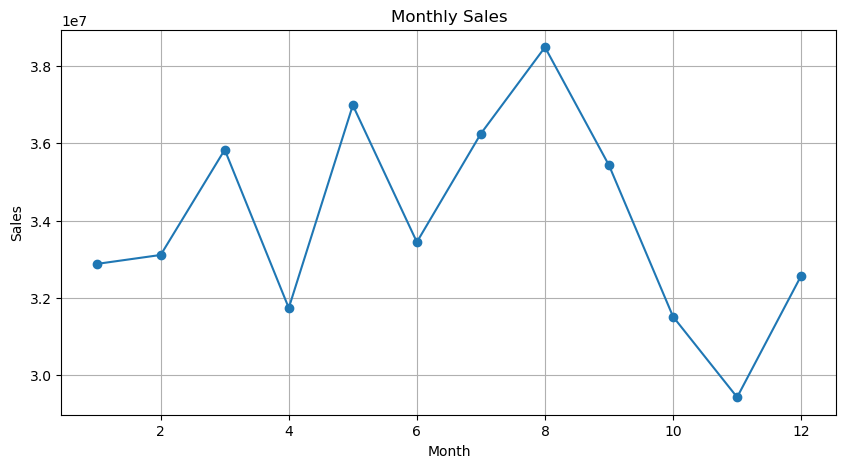

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [18]:
category_sales = df.groupby("category")["total_sales"].sum()

category_sales

category
Beauty               2891445.5
Books                4685924.0
Clothing            15858690.0
Electronics        248256515.0
Furniture          106637525.0
Grocery              1971371.5
Home Appliances     16439255.0
Sports              10940730.0
Name: total_sales, dtype: float64

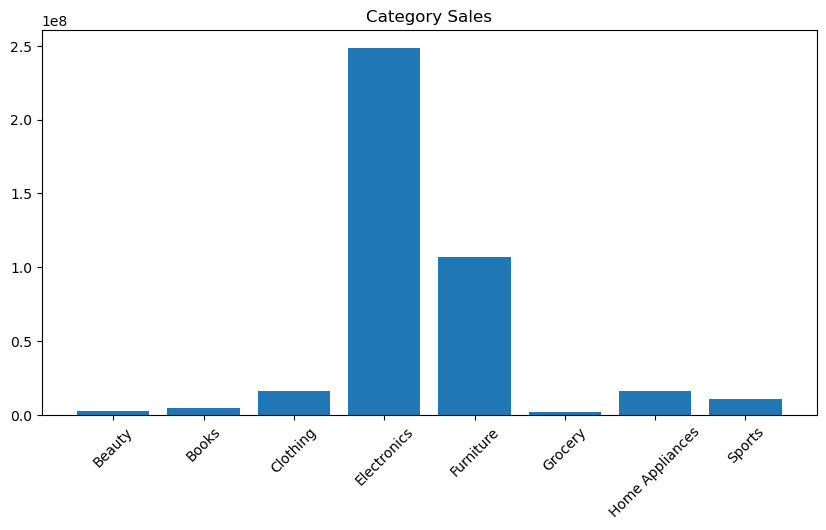

In [19]:
plt.figure(figsize=(10,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.xticks(rotation=45)

plt.title("Category Sales")

plt.show()

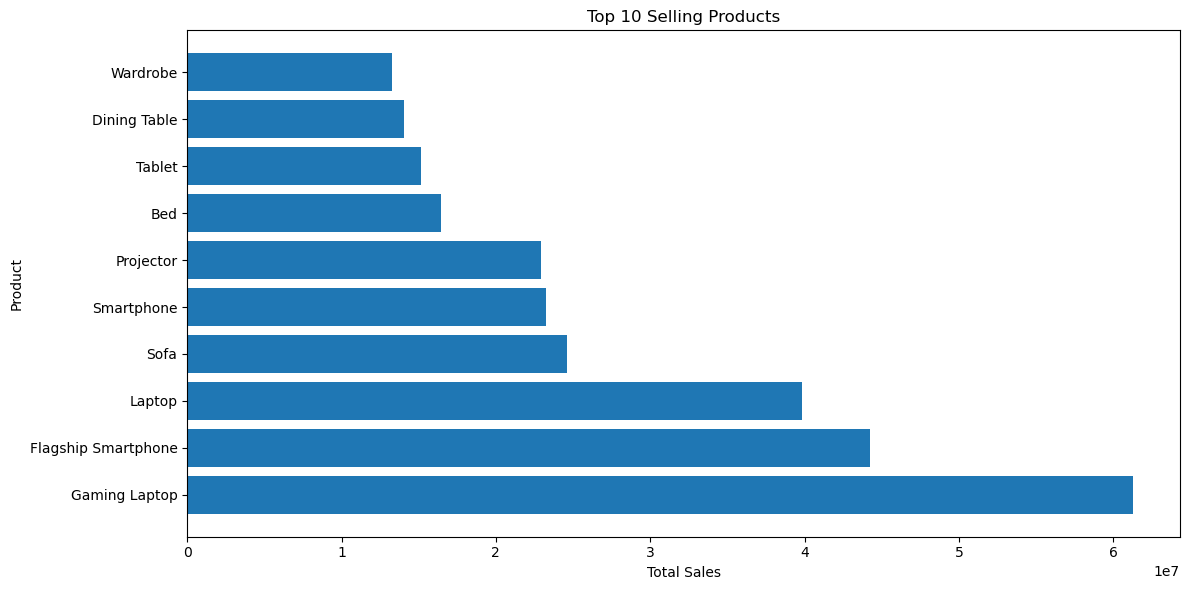

In [24]:
top_products = (
    df.groupby("product_name")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(top_products.index, top_products.values)

plt.title("Top 10 Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

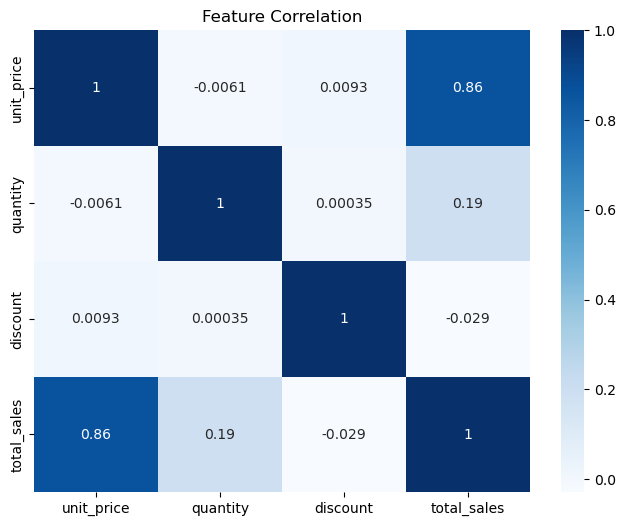

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["unit_price","quantity","discount","total_sales"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")

plt.show()

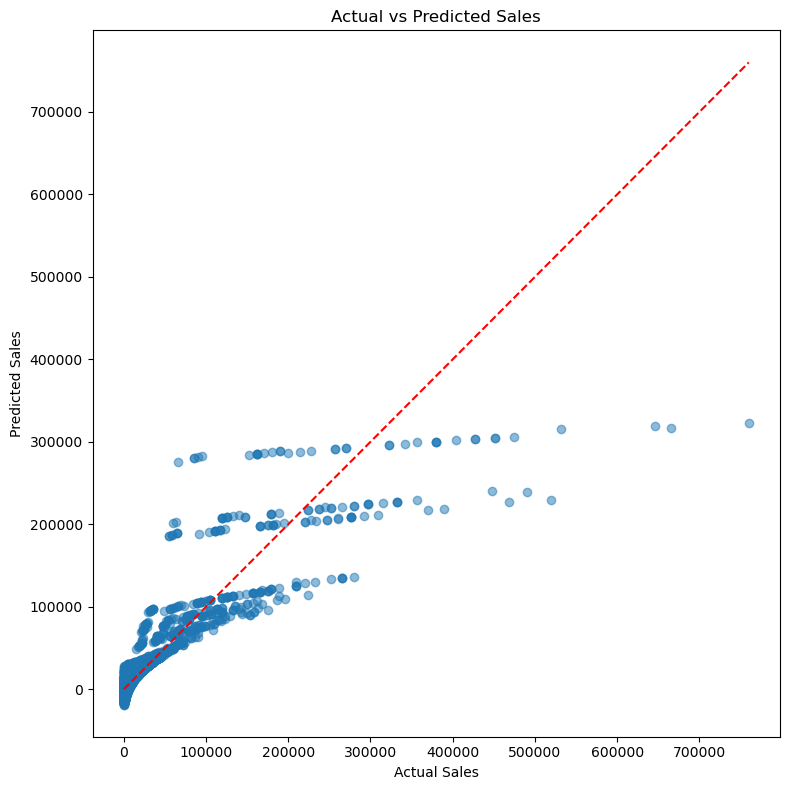

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[["unit_price", "quantity", "discount"]]

# Target
y = df["total_sales"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

plt.figure(figsize=(8, 8))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

In [20]:
top_products = (
    df.groupby("product_name")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Gaming Laptop          61246500.0
Flagship Smartphone    44257500.0
Laptop                 39822250.0
Sofa                   24627750.0
Smartphone             23220000.0
Projector              22946000.0
Bed                    16433200.0
Tablet                 15156900.0
Dining Table           14015100.0
Wardrobe               13299600.0
Name: total_sales, dtype: float64

In [21]:
top_cities = (
    df.groupby("city")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

top_cities

city
Delhi            35664545.00
Indore           34397493.75
Visakhapatnam    31301792.50
Jaipur           31088019.50
Pune             27396422.25
Mumbai           26502340.50
Kolkata          25783575.75
Nagpur           25471161.75
Bangalore        24994167.50
Ahmedabad        24971790.25
Lucknow          24925583.00
Chennai          24365024.75
Hyderabad        23813006.50
Coimbatore       23698672.75
Kochi            23307860.25
Name: total_sales, dtype: float64